# MNIST Handwritten Digit Recognition using Deep Learning

#### Load MNIST data and understand

In [23]:
import tensorflow as tf
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [41]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

In [25]:
# load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [26]:
print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)

print("Testing data shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28)
Testing labels shape: (10000,)


    60,000 images, each image is 28×28 pixels means 28 rows and 28 columns.

    In deep learning, data is stored as tensors.
    A tensor is basically:

    - scalar → single number
    - vector → 1D array
    - matrix → 2D array
    - tensor → multi-dimensional array

    (60000, 28, 28) is 3D Tensor

In [36]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [29]:
print(y_train[0]) # handwritten number 5

5


#### Mini Visualization Task

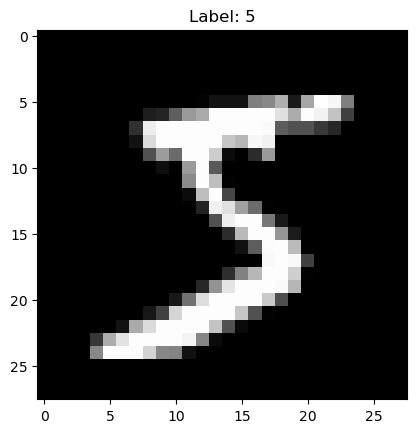

In [30]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

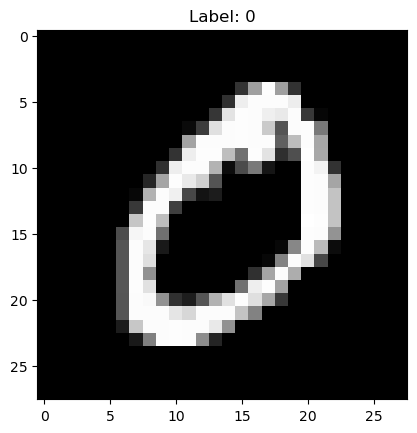

In [49]:
import matplotlib.pyplot as plt

plt.imshow(x_train[1], cmap='gray')
plt.title(f"Label: {y_train[1]}")
plt.show()

### Data Normalization

    current pixel values: 0 to 255
    normalize to: 0 to 1

In [37]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [39]:
print(x_train[0][23])

[0.         0.         0.         0.         0.21568627 0.6745098
 0.88627451 0.99215686 0.99215686 0.99215686 0.99215686 0.95686275
 0.52156863 0.04313725 0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.        ]


<b>Each image has 28 × 28 = 784 pixels

<b>DL Basic concepts:</b>
    
    Neurons: a tiny decision-making unit.
    Input Layer: Receives image pixels. (784 pixel per image)
    Hidden Layer: Learns the patterns like curves, sharpnessm edges etc
    Output Layer: Predicts Digit [0 to 9]. So we need 10 output neurons. One for each digit.

    - Activation Function: f(x)=max(0,x)
    Meaning: negative values become 0 and positive values stay
    Why?
    It helps neural networks learn complex patterns.
    
    - Softmax: 
    Output Layer uses softmax to convert outputs into probabilities.
    Example, digit 5 -> 7%
    Highest probability = prediction.
    


### Building a Neural Network

In [46]:
model = Sequential([
    
    # convert 28x28 image matrix into 1D array (1D array contains 784 numbers)
    Flatten(input_shape=(28, 28)),
    
    # hidden layer
    # 128 neurons in hidden layer
    Dense(128, activation='relu'), 
    
    # output layer
    # 10 output neurons
    Dense(10, activation='softmax')
])

In [47]:
# show model structure
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

    (784×128)+128 = 100,480 parameters

    784 inputs connected to 128 neurons plus 128 bias values. 
    These are the values network learns during training.

### Compile the Model

In [48]:
# Compile the Model 
# before training configure the optimizer, loss, metrics
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Train the Neural Network

In [50]:
history = model.fit(
    x_train,
    y_train,
    epochs=5
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9246 - loss: 0.2607
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9654 - loss: 0.1168 
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9760 - loss: 0.0795 
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9815 - loss: 0.0604
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9850 - loss: 0.0476


    Epoch: one complete pass through the entire training dataset. 60,000 images seen once = 1 epoch
    Backpropagation: calculate error and send it backwards and update weights
    Gradient Descent: How the weights are updated. move weights in direction that reduces error

### Evaluate on Test Data

In [51]:
# Generalization - test on data the model has NEVER seen before.Else, model will just memorize.
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9746 - loss: 0.0778
Test Loss: 0.07776002585887909
Test Accuracy: 0.9746000170707703


    In our case it performed well. 
        train acc = 98%  
        test acc  = 97%.
        
    But, what is Overfitting ? 
        Training Accuracy = very high
        Testing Accuracy = much lower
        Means, model memorized training data instead of learning general patterns.
        So always compare test and train accuracies.

### Make Predictions

In [54]:
predictions = model.predict(x_test)

print(predictions[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step  
[5.2009675e-08 3.2383596e-08 2.5748136e-06 1.2303039e-04 7.0883538e-12
 2.8731361e-07 3.4735767e-12 9.9985623e-01 1.0602766e-06 1.6713926e-05]


In [56]:
# convert probabilities into actual prediction

import numpy as np

# finds the highest value/prob and returns it's index 
predicted_label = np.argmax(predictions[0])

print("Predicted:", predicted_label)
print("Actual:", y_test[0])

Predicted: 7
Actual: 7


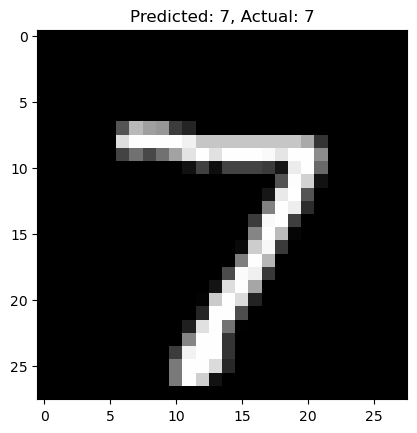

In [57]:
plt.imshow(x_test[0], cmap='gray')
plt.title(f"Predicted: {predicted_label}, Actual: {y_test[0]}")
plt.show()